In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print("✅ TensorFlow:", tf.__version__)
print("✅ All imports successful!")

2026-04-01 23:41:13.673394: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ TensorFlow: 2.16.2
✅ All imports successful!


In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
)

# Validation — no augmentation, just normalize
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    "data/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

print("\nClass mapping:", train_data.class_indices)

Found 7260 images belonging to 12 classes.
Found 1817 images belonging to 12 classes.

Class mapping: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


In [3]:
# Load MobileNetV2 without top layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze base

# Custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
output = Dense(12, activation="softmax")(x)  # ← 12 classes now

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model built successfully!")
print(f"Total layers: {len(model.layers)}")
print(f"Trainable layers: {len([l for l in model.layers if l.trainable])}")

✅ Model built successfully!
Total layers: 158
Trainable layers: 4


In [4]:
# Auto-compute class weights from actual folder counts
CLASS_NAMES = sorted(os.listdir("data/train"))
class_counts = np.array([
    len(os.listdir(f"data/train/{c}")) for c in CLASS_NAMES
])
total = class_counts.sum()
n_classes = len(CLASS_NAMES)

class_weights = {
    i: total / (n_classes * count)
    for i, count in enumerate(class_counts)
}

print("Class weights:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls} ({i}): {class_weights[i]:.2f}")

print("\n✅ Class weights ready!")

Class weights:
  battery (0): 0.95
  biological (1): 0.95
  brown-glass (2): 1.25
  cardboard (3): 0.95
  clothes (4): 0.95
  green-glass (5): 1.20
  metal (6): 0.98
  paper (7): 0.95
  plastic (8): 0.95
  shoes (9): 0.95
  trash (10): 1.09
  white-glass (11): 0.98

✅ Class weights ready!


In [5]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    class_weight=class_weights
)

print("\n✅ Training complete!")

Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.7580 - loss: 0.7698 - val_accuracy: 0.8542 - val_loss: 0.4229
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 335s 1s/step - accuracy: 0.8601 - loss: 0.4226 - val_accuracy: 0.8855 - val_loss: 0.3550
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.8810 - loss: 0.3582 - val_accuracy: 0.8971 - val_loss: 0.3253
Epoch 4/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/step - accuracy: 0.8945 - loss: 0.3187 - val_accuracy: 0.8932 - val_loss: 0.3282
Epoch 5/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.9043 - loss: 0.2875 - val_accuracy: 0.9004 - val_loss: 0.3029
Epoch 6/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.9092 - loss: 0.2560 - val_accuracy: 0.8938 - val_loss: 0.3311
Epoch 7/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.9134 - loss: 0.2508 - val_accuracy: 0.9015 - val_loss: 0.2905
Epoch 8/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9198 - loss: 0.2401 - val_accu

In [6]:
model.save("model/model.h5")
print("✅ Model saved to model/model.h5")

✅ Model saved to model/model.h5


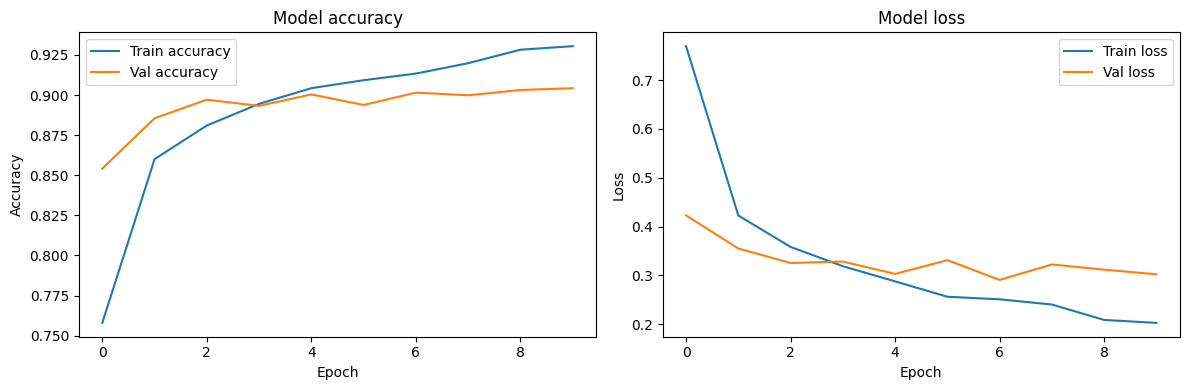

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val accuracy")
axes[0].set_title("Model accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train loss")
axes[1].plot(history.history["val_loss"], label="Val loss")
axes[1].set_title("Model loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


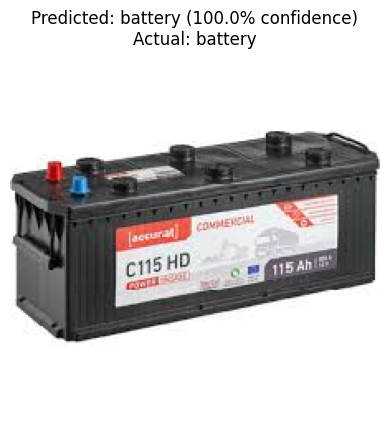

In [8]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load saved model
loaded_model = load_model("model/model.h5")

# Class names must match folder order Keras used
CLASS_NAMES = sorted(os.listdir("data/val"))

# Pick a random test image from any val class
random_class = CLASS_NAMES[0]  # change to any class you want to test
test_img_path = f"data/val/{random_class}/" + os.listdir(f"data/val/{random_class}")[0]

img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = loaded_model.predict(img_array)
predicted_class = CLASS_NAMES[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show result
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence:.1f}% confidence)\nActual: {random_class}")
plt.axis("off")
plt.show()